In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ==========================================
# 1. CONFIGURATION & LOADING
# ==========================================
ANCHOR_DATE = pd.Timestamp("2026-01-20")

# Load Datasets
df_target = pd.read_csv('futu_margin_ratios_all_target.csv')
df_history = pd.read_csv('full_market_history_raw.csv')
df_shares = pd.read_csv('circulating_shares_report.csv')
df_map = pd.read_csv('LB_futu_mapping.csv')

# Load Basic Info & Supplement
df_basic_main = pd.read_csv('futu_us_stock_basic_info.csv')
df_basic_supp = pd.read_csv('stock_static_info_supp.csv')

# --- MERGE STATIC INFO ---
print(f"Basic Info Main: {len(df_basic_main)} rows")
print(f"Basic Info Supp: {len(df_basic_supp)} rows")

# Combine and drop duplicates (Prioritizing the Main file)
df_basic = pd.concat([df_basic_main, df_basic_supp], ignore_index=True)
df_basic = df_basic.drop_duplicates(subset='code', keep='first')

print(f"Combined Basic Info: {len(df_basic)} unique stocks")
print("-" * 30)

# ==========================================
# 2. THE BRIDGE (MAPPING STRATEGY)
# ==========================================
# Create a dictionary for fast lookup: LB_ticker -> futu_ticker
lb_to_futu_dict = dict(zip(df_map['LB_ticker'], df_map['futu_ticker']))

def get_futu_key(lb_symbol):
    if lb_symbol in lb_to_futu_dict:
        return lb_to_futu_dict[lb_symbol]
    if str(lb_symbol).endswith('.US'):
        clean_sym = str(lb_symbol).replace('.US', '')
        return f"US.{clean_sym}"
    return f"US.{lb_symbol}"

print("Bridging LB data to Futu keys...")
df_history['futu_key'] = df_history['Symbol'].apply(get_futu_key)
df_shares['futu_key'] = df_shares['Symbol'].apply(get_futu_key)

# ==========================================
# 3. MASTER TABLE & HARD FILTERS
# ==========================================
# Merge Target with the Combined Basic Info
df_master = pd.merge(df_target, df_basic, on='code', how='left')

# --- Filter 1: Pink Sheets ---
# Handling N/A in exchange_type by treating them as 'Unknown' (safe path) or filling
df_master['exchange_type'] = df_master['exchange_type'].fillna('Unknown')
pink_exchanges = ['US_PINK', 'PINK', 'OTC'] 
df_master['is_pink'] = df_master['exchange_type'].isin(pink_exchanges)

# --- Filter 2: New Listings (< 3 Months) ---
df_master['listing_date'] = pd.to_datetime(df_master['listing_date'], errors='coerce')
df_master['days_listed'] = (ANCHOR_DATE - df_master['listing_date']).dt.days

# Handle missing listing dates:
# If listing date is missing, we usually assume it's NOT new (safest for established stocks), 
# or strictly filter it out. Here we assume False (not new) if unknown, unless you prefer strictness.
df_master['is_new'] = df_master['days_listed'] < 90
df_master['is_new'] = df_master['is_new'].fillna(False) 

# Create Training Set (Eligible Only)
# We exclude Pink and New stocks from the Logistic Regression training
train_mask = (~df_master['is_pink']) & (~df_master['is_new'])
df_train = df_master[train_mask].copy()

print(f"Total Targets: {len(df_master)}")
print(f"Eligible for Model: {len(df_train)} (Excluded {len(df_master) - len(df_train)} via Hard Rules)")

# ==========================================
# 4. FEATURE ENGINEERING
# ==========================================

# --- Feature A: Log(30-Day Avg Turnover) ---
# 1. Filter History by Date
df_hist_filt = df_history[pd.to_datetime(df_history['Date']) < ANCHOR_DATE].copy()

# 2. Sort by Date Descending
df_hist_filt = df_hist_filt.sort_values(['futu_key', 'Date'], ascending=[True, False])

# 3. Take Top 30 per stock
df_hist_top30 = df_hist_filt.groupby('futu_key').head(30)

# 4. Calculate Mean Turnover
turnover_feat = df_hist_top30.groupby('futu_key')['Turnover'].mean().reset_index()
turnover_feat.rename(columns={'Turnover': 'avg_turnover_30d'}, inplace=True)

# --- Feature B: Log(Market Cap) ---
# 1. Get Latest Price (from history, just the top 1 row)
latest_price = df_hist_filt.groupby('futu_key').head(1)[['futu_key', 'Close']].rename(columns={'Close': 'latest_close'})

# 2. Get Shares (from shares report)
shares_feat = df_shares[['futu_key', 'Total Shares']].copy()

# 3. Calculate Cap
cap_df = pd.merge(latest_price, shares_feat, on='futu_key', how='inner')
cap_df['market_cap'] = cap_df['latest_close'] * cap_df['Total Shares']

# --- Merge Features into Master Training Set ---
df_model = pd.merge(df_train, turnover_feat, left_on='code', right_on='futu_key', how='inner')
df_model = pd.merge(df_model, cap_df[['futu_key', 'market_cap']], on='futu_key', how='inner')

# --- Log Transformation ---
# Using log1p to avoid errors with 0
df_model['log_turnover'] = np.log1p(df_model['avg_turnover_30d'])
df_model['log_mkt_cap'] = np.log1p(df_model['market_cap'])

# ==========================================
# 5. LOGISTIC REGRESSION MODEL
# ==========================================
features = ['log_turnover', 'log_mkt_cap']
target = 'is_long_permit'

# Drop any remaining NAs
df_model_clean = df_model.dropna(subset=features + [target])

X = df_model_clean[features]
y = df_model_clean[target].astype(int) # Convert boolean to 0/1

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
clf = LogisticRegression()
clf.fit(X_train, y_train)

# ==========================================
# 6. EVALUATION
# ==========================================
print("\n--- Model Coefficients ---")
print(f"Intercept: {clf.intercept_[0]:.4f}")
print(f"Coeff (Log Turnover): {clf.coef_[0][0]:.4f}")
print(f"Coeff (Log Mkt Cap): {clf.coef_[0][1]:.4f}")

y_prob = clf.predict_proba(X_test)[:, 1]

# CHANGE: Custom Threshold 0.65
THRESHOLD = 0.65
y_pred_custom = (y_prob >= THRESHOLD).astype(int)

print(f"\n--- Performance Metrics (Threshold: {THRESHOLD}) ---")
print(classification_report(y_test, y_pred_custom))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# ==========================================
# 7. DEEP DIVE ANALYSIS & MASTER INFERENCE REPORT
# ==========================================
print("\n" + "="*40)
print("GENERATING MASTER INFERENCE REPORT (JAN 20 + JAN 2)")
print("="*40)

# --- CONFIGURATION ---
THRESHOLD = 0.65  # Strict threshold
DATE_JAN2 = pd.Timestamp("2026-01-02")

# ---------------------------------------------------------
# PART A: CURRENT STATUS (JAN 20) - The Standard Inference
# ---------------------------------------------------------

# 1. Prepare Data
X_full = df_model_clean[features]
df_inference = df_model_clean.copy()

# 2. Predict (Jan 20)
df_inference['p_allow_long'] = clf.predict_proba(X_full)[:, 1]
df_inference['pred_allow_long'] = (df_inference['p_allow_long'] >= THRESHOLD).astype(int)
df_inference['is_long_permit'] = df_inference['is_long_permit'].astype(int)

# 3. Calculate Confusion Category (Jan 20)
def get_confusion_category(actual, pred):
    if actual == 1 and pred == 1: return 'TP (Valid Approval)'
    if actual == 0 and pred == 1: return 'FP (Risky Approval)'
    if actual == 1 and pred == 0: return 'FN (Missed Opp)'
    if actual == 0 and pred == 0: return 'TN (Correct Ban)'
    return 'Error'

df_inference['confusion_matrix'] = df_inference.apply(
    lambda row: get_confusion_category(row['is_long_permit'], row['pred_allow_long']), axis=1
)

df_inference['match'] = df_inference['is_long_permit'] == df_inference['pred_allow_long']

# ---------------------------------------------------------
# PART B: HISTORICAL STATUS (JAN 2) - The Backtest Inference
# ---------------------------------------------------------
print("Calculating Historical Features (Jan 2)...")

# 1. Load Jan 2 Targets
try:
    df_target_jan2 = pd.read_csv('futu_margin_ratios_all_target_2/1.csv')
except:
    df_target_jan2 = pd.read_csv('futu_margin_ratios_all_1:2.csv') # Fallback

# 2. Calculate Jan 2 Features (Full Universe)
# Filter History < Jan 2
df_hist_jan2 = df_history[pd.to_datetime(df_history['Date']) < DATE_JAN2].copy()
df_hist_jan2 = df_hist_jan2.sort_values(['futu_key', 'Date'], ascending=[True, False])

# Aggregations
jan2_turnover = df_hist_jan2.groupby('futu_key').head(30).groupby('futu_key')['Turnover'].mean()
jan2_price = df_hist_jan2.groupby('futu_key').head(1).set_index('futu_key')['Close']
jan2_shares = df_shares.drop_duplicates(subset=['futu_key']).set_index('futu_key')['Total Shares']

# Assemble Jan 2 Feature Table
df_jan2 = pd.DataFrame({
    'avg_turnover': jan2_turnover,
    'close_price': jan2_price,
    'total_shares': jan2_shares
}).dropna()

# Log Transform
df_jan2['log_turnover'] = np.log1p(df_jan2['avg_turnover'])
df_jan2['log_mkt_cap'] = np.log1p(df_jan2['close_price'] * df_jan2['total_shares'])

# 3. Predict (Jan 2)
# Note: We use the same 'clf' model trained on Jan 20 data
X_jan2 = df_jan2[['log_turnover', 'log_mkt_cap']]
df_jan2['p_allow_long_jan2'] = clf.predict_proba(X_jan2)[:, 1]
df_jan2['pred_allow_long_jan2'] = (df_jan2['p_allow_long_jan2'] >= THRESHOLD).astype(int)

# 4. Merge Jan 2 Targets
df_jan2 = df_jan2.reset_index().rename(columns={'futu_key': 'code'}) # Index was futu_key
df_jan2 = pd.merge(df_jan2, df_target_jan2[['code', 'is_long_permit']], on='code', how='inner')
df_jan2 = df_jan2.rename(columns={'is_long_permit': 'is_long_permit_jan2'})
df_jan2['is_long_permit_jan2'] = df_jan2['is_long_permit_jan2'].astype(int)

# 5. Calculate Jan 2 Confusion
df_jan2['confusion_matrix_jan2'] = df_jan2.apply(
    lambda row: get_confusion_category(row['is_long_permit_jan2'], row['pred_allow_long_jan2']), axis=1
)

# ---------------------------------------------------------
# PART C: MERGE & EXPORT
# ---------------------------------------------------------
print("Merging Datasets...")

# Select columns for Jan 20 (Base)
cols_jan20 = [
    'code', 'log_turnover', 'log_mkt_cap', 'exchange_type', 'listing_date',
    'is_long_permit', 'pred_allow_long', 'p_allow_long', 'match', 'confusion_matrix'
]
df_final = df_inference[cols_jan20].rename(columns={
    'code': 'ticker',
    'log_turnover': 'log_adt',
    'log_mkt_cap': 'log_mcap'
})

# Select columns for Jan 2 (To Append)
cols_jan2 = [
    'code', 'log_turnover', 'log_mkt_cap', 
    'is_long_permit_jan2', 'pred_allow_long_jan2', 'p_allow_long_jan2', 'confusion_matrix_jan2'
]
df_jan2_clean = df_jan2[cols_jan2].rename(columns={
    'log_turnover': 'log_adt_jan2',
    'log_mkt_cap': 'log_mcap_jan2'
})

# Left Join: Keep all current (Jan 20) stocks, add Jan 2 history where available
df_report = pd.merge(df_final, df_jan2_clean, left_on='ticker', right_on='code', how='left')
df_report.drop(columns=['code'], inplace=True) # clean up redundant join key

# --- METRICS REPORTING ---
# Calc FPR for Jan 20 (Current)
tn, fp, fn, tp = confusion_matrix(df_inference['is_long_permit'], df_inference['pred_allow_long']).ravel()
fpr = fp / (tn + fp) if (tn + fp) > 0 else 0

print("\n--- Current Model Risks (Jan 20 Data, Threshold {:.2f}) ---".format(THRESHOLD))
print(f"False Positive Rate (FPR): {fpr:.2%}")
print(f"Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# --- EXPORT ---
filename = 'margin_model_inference_report.csv'
df_report.to_csv(filename, index=False)
print(f"\n✅ Report Generated: {filename}")
print("Contains columns for both Current (Jan 20) and Backtest (Jan 2) data.")

# Optional: Master sheet dump
df_master.to_csv('futu_margin_ratios_master_sheet.csv', index=False)

# ==========================================
# 8. STRICT HISTORICAL BACKTEST (Recalculating for Jan 2nd)
# ==========================================
print("\n" + "="*40)
print("RUNNING STRICT BACKTEST (Feature Cutoff: JAN 2nd)")
print("="*40)

# *** CONFIGURATION ***
THRESHOLD = 0.65
BACKTEST_DATE = pd.Timestamp("2026-01-02") 

# 1. Load the Old Target Data
try:
    df_old_target = pd.read_csv('futu_margin_ratios_all_target_2/1.csv')
except FileNotFoundError:
    print("⚠️ File not found. Checking alternate naming...")
    df_old_target = pd.read_csv('futu_margin_ratios_all_1:2.csv')

# 2. Define the Stocks to Check
target_tickers = ['US.MMC', 'US.FYBR', 'US.ERO', 'US.HOUS', 'US.MNMD', 'US.CVAC']

# 3. RECALCULATE FEATURES (Using ONLY data < Jan 2nd)
df_hist_backtest = df_history[pd.to_datetime(df_history['Date']) < BACKTEST_DATE].copy()
df_hist_backtest = df_hist_backtest.sort_values(['futu_key', 'Date'], ascending=[True, False])

# A. Turnover
df_hist_bt_top30 = df_hist_backtest.groupby('futu_key').head(30)
bt_turnover = df_hist_bt_top30.groupby('futu_key')['Turnover'].mean().reset_index()
bt_turnover.rename(columns={'Turnover': 'avg_turnover_30d_JAN2'}, inplace=True)

# B. Market Cap
bt_price = df_hist_backtest.groupby('futu_key').head(1)[['futu_key', 'Close']]
bt_price.rename(columns={'Close': 'close_price_JAN2'}, inplace=True)

bt_cap = pd.merge(bt_price, df_shares[['futu_key', 'Total Shares']], on='futu_key', how='inner')
bt_cap['market_cap_JAN2'] = bt_cap['close_price_JAN2'] * bt_cap['Total Shares']

# 4. Prepare Dataset
df_bt_features = pd.merge(bt_turnover, bt_cap[['futu_key', 'market_cap_JAN2']], on='futu_key', how='inner')
df_bt_features['log_turnover'] = np.log1p(df_bt_features['avg_turnover_30d_JAN2'])
df_bt_features['log_mkt_cap'] = np.log1p(df_bt_features['market_cap_JAN2'])

# 5. Merge with Targets
df_test_set = df_old_target[df_old_target['code'].isin(target_tickers)][['code', 'is_long_permit']]
df_test_set.rename(columns={'is_long_permit': 'actual_status_JAN2'}, inplace=True)
df_final_bt = pd.merge(df_test_set, df_bt_features, left_on='code', right_on='futu_key', how='left')

# 6. Run Prediction (Manual Threshold)
if not df_final_bt.empty:
    X_bt = df_final_bt[['log_turnover', 'log_mkt_cap']]
    X_bt = X_bt.dropna()
    
    # --- CHANGED: Use Threshold 0.65 ---
    probs = clf.predict_proba(X_bt)[:, 1]
    df_final_bt['model_prob_JAN2'] = probs
    df_final_bt['model_pred_JAN2'] = (probs >= THRESHOLD).astype(int)
    
    # 7. Output Results
    print(f"\nStrict Backtest Results (Data < {BACKTEST_DATE.date()} | Threshold {THRESHOLD}):\n")
    
    for index, row in df_final_bt.iterrows():
        ticker = row['code']
        actual = "Allow" if row['actual_status_JAN2'] else "Ban"
        pred = "Allow" if row['model_pred_JAN2'] == 1 else "Ban"
        prob = row['model_prob_JAN2']
        
        match = (row['actual_status_JAN2'] == row['model_pred_JAN2'])
        result_icon = "✅" if match else "❌"
        
        print(f"{ticker}:")
        print(f"   Real Status (Jan 2): {actual}")
        print(f"   Model Logic (Jan 2): {pred} (Prob: {prob:.1%}) {result_icon}")
        
        if not match:
            print("   -> Disagreement: The model logic differed from the status on Jan 2.")
        print("-" * 30)

else:
    print("Error: No history found for these tickers prior to Jan 2nd.")

# ==========================================
# 9. GENERATE CSV REPORT (JAN 2 vs JAN 20)
# ==========================================
print("\n" + "="*40)
print("GENERATING HEAD-TO-HEAD REPORT (JAN 2 vs JAN 20)")
print("="*40)

# Configuration
DATE_JAN2  = pd.Timestamp("2026-01-02")
DATE_JAN20 = pd.Timestamp("2026-01-20")
THRESHOLD = 0.65  # Ensure this matches above

compare_tickers = ['US.MMC', 'US.FYBR', 'US.ERO', 'US.HOUS', 'US.MNMD', 'US.CVAC']

# --- STEP 1: JAN 2 DATA ---
try:
    df_target_jan2 = pd.read_csv('futu_margin_ratios_all_target_2/1.csv')
except:
    df_target_jan2 = pd.read_csv('futu_margin_ratios_all_1:2.csv')

df_hist_jan2 = df_history[pd.to_datetime(df_history['Date']) < DATE_JAN2].copy()
df_hist_jan2 = df_hist_jan2.sort_values(['futu_key', 'Date'], ascending=[True, False])

jan2_turnover = df_hist_jan2.groupby('futu_key').head(30).groupby('futu_key')['Turnover'].mean()
jan2_price = df_hist_jan2.groupby('futu_key').head(1).set_index('futu_key')['Close']
jan2_shares = df_shares.drop_duplicates(subset=['futu_key']).set_index('futu_key')['Total Shares']

df_jan2 = pd.DataFrame({
    'avg_turnover': jan2_turnover,
    'close_price': jan2_price,
    'total_shares': jan2_shares
}).dropna()

df_jan2['log_turnover'] = np.log1p(df_jan2['avg_turnover'])
df_jan2['log_mkt_cap'] = np.log1p(df_jan2['close_price'] * df_jan2['total_shares'])

X_jan2 = df_jan2[['log_turnover', 'log_mkt_cap']]
df_jan2['p_model_jan2'] = clf.predict_proba(X_jan2)[:, 1]

# --- STEP 2: JAN 20 DATA ---
df_jan20_subset = df_model_clean[df_model_clean['code'].isin(compare_tickers)].copy()
df_jan20_subset = df_jan20_subset[['code', 'is_long_permit', 'log_turnover', 'log_mkt_cap']]

X_jan20 = df_jan20_subset[['log_turnover', 'log_mkt_cap']]
df_jan20_subset['p_model_jan20'] = clf.predict_proba(X_jan20)[:, 1]

# --- STEP 3: MERGE & FORMAT ---
df_jan2_final = df_jan2.reset_index().rename(columns={'futu_key': 'code'})
df_jan2_final = pd.merge(df_jan2_final, df_target_jan2[['code', 'is_long_permit']], on='code', how='inner')
df_jan2_final = df_jan2_final.rename(columns={'is_long_permit': 'actual_jan2'})

df_jan20_final = df_jan20_subset.rename(columns={'is_long_permit': 'actual_jan20'})

df_compare = pd.merge(df_jan2_final[['code', 'actual_jan2', 'p_model_jan2']], 
                      df_jan20_final[['code', 'actual_jan20', 'p_model_jan20']], 
                      on='code', how='inner')

df_compare = df_compare[df_compare['code'].isin(compare_tickers)]

# --- STEP 4: APPLY THRESHOLD & EXPORT ---
# Convert probabilities to "Allow/Ban" using 0.65
df_compare['model_decision_jan2'] = df_compare['p_model_jan2'].apply(lambda x: "Allow" if x >= THRESHOLD else "Ban")
df_compare['model_decision_jan20'] = df_compare['p_model_jan20'].apply(lambda x: "Allow" if x >= THRESHOLD else "Ban")

# Format Actuals
df_compare['actual_jan2'] = df_compare['actual_jan2'].apply(lambda x: "Allow" if x else "Ban")
df_compare['actual_jan20'] = df_compare['actual_jan20'].apply(lambda x: "Allow" if x else "Ban")
df_compare['status_change'] = df_compare['actual_jan2'] + " -> " + df_compare['actual_jan20']

# Updated Column List (includes probabilities AND decisions)
cols = [
    'code', 
    'status_change', 
    'actual_jan2', 'model_decision_jan2', 'p_model_jan2', 
    'actual_jan20', 'model_decision_jan20', 'p_model_jan20'
]
df_compare = df_compare[cols]

csv_filename = 'comparison_report_jan2_vs_jan20.csv'
df_compare.to_csv(csv_filename, index=False)

print("\nSample Output:")
print(df_compare.to_string(index=False))
print(f"\n✅ CSV saved as: {csv_filename} (Threshold used: {THRESHOLD})")




Basic Info Main: 13084 rows
Basic Info Supp: 177 rows
Combined Basic Info: 13259 unique stocks
------------------------------
Bridging LB data to Futu keys...
Total Targets: 4151
Eligible for Model: 3932 (Excluded 219 via Hard Rules)

--- Model Coefficients ---
Intercept: -24.2489
Coeff (Log Turnover): 0.4993
Coeff (Log Mkt Cap): 0.7491

--- Performance Metrics (Threshold: 0.65) ---
              precision    recall  f1-score   support

           0       0.76      0.90      0.83       353
           1       0.91      0.77      0.83       434

    accuracy                           0.83       787
   macro avg       0.83      0.84      0.83       787
weighted avg       0.84      0.83      0.83       787

ROC-AUC Score: 0.9095

GENERATING MASTER INFERENCE REPORT (JAN 20 + JAN 2)
Calculating Historical Features (Jan 2)...
Merging Datasets...

--- Current Model Risks (Jan 20 Data, Threshold 0.65) ---
False Positive Rate (FPR): 12.08%
Matrix: TN=1594, FP=219, FN=561, TP=1560

✅ Report Gener

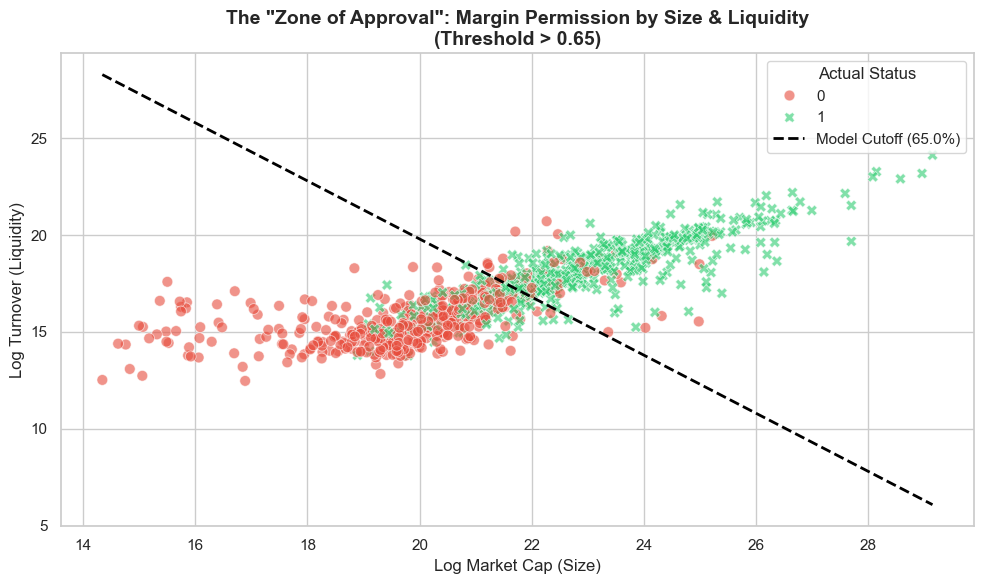

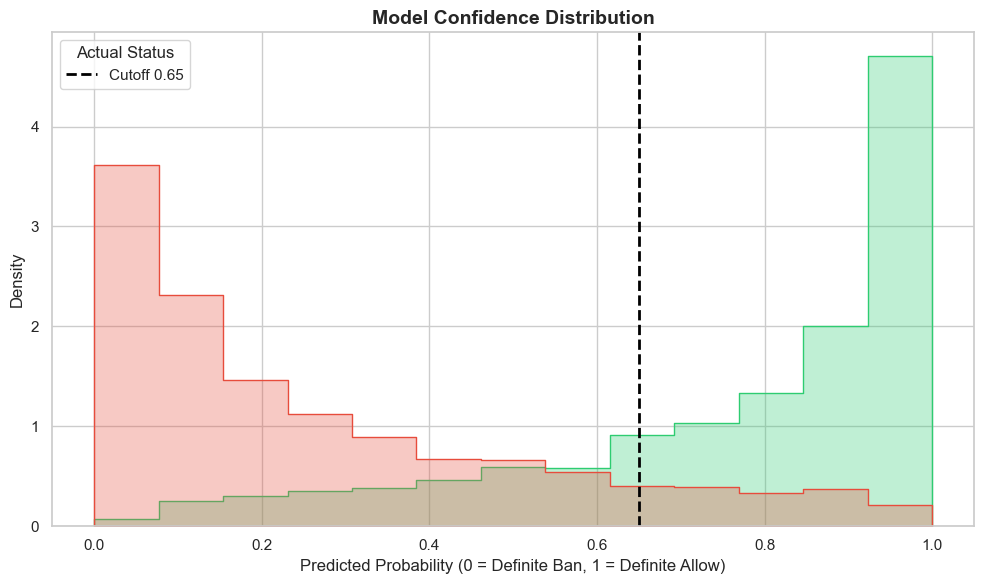

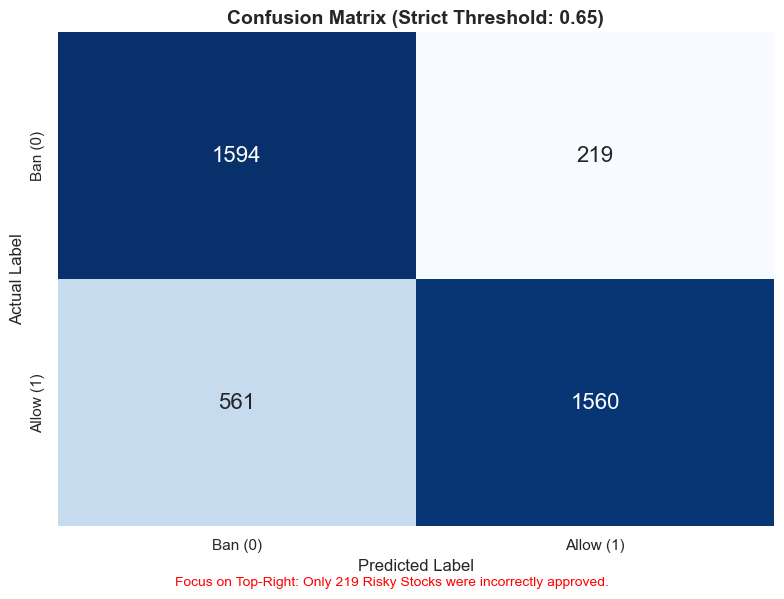

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set style for presentation
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# PLOT 1: THE "ZONE OF APPROVAL" (Decision Boundary)
# ==========================================
# This is the most important plot. It shows exactly where the model draws the line.

plt.figure(figsize=(10, 6))

# 1. Plot the actual data points
# We sample 1000 points to keep the chart clean, or use all if dataset is small
plot_data = df_inference.sample(n=min(1000, len(df_inference)), random_state=42)

sns.scatterplot(
    data=plot_data,
    x='log_mkt_cap',
    y='log_turnover',
    hue='is_long_permit',  # Color by ACTUAL status
    style='is_long_permit',
    palette={0: '#e74c3c', 1: '#2ecc71'}, # Red for Ban, Green for Allow
    alpha=0.6,
    s=60
)

# 2. Draw the Decision Boundary Line (for Threshold = 0.65)
# Equation: ln(p / (1-p)) = b0 + b1*x1 + b2*x2
# x2 (Turnover) = [ln(0.65/0.35) - b0 - b1*x1 (Cap)] / b2
b0 = clf.intercept_[0]
b1 = clf.coef_[0][1] # Cap coeff (check index based on X columns order)
b2 = clf.coef_[0][0] # Turnover coeff

# Create x-axis range (Market Cap)
x_vals = np.linspace(plot_data['log_mkt_cap'].min(), plot_data['log_mkt_cap'].max(), 100)
# Calculate threshold logit
logit_threshold = np.log(THRESHOLD / (1 - THRESHOLD))
# Calculate y-axis (Turnover)
y_vals = (logit_threshold - b0 - (b1 * x_vals)) / b2

plt.plot(x_vals, y_vals, color='black', linewidth=2, linestyle='--', label=f'Model Cutoff ({THRESHOLD*100}%)')

# Labels & Titles
plt.title(f'The "Zone of Approval": Margin Permission by Size & Liquidity\n(Threshold > {THRESHOLD})', fontsize=14, fontweight='bold')
plt.xlabel('Log Market Cap (Size)', fontsize=12)
plt.ylabel('Log Turnover (Liquidity)', fontsize=12)
plt.legend(title='Actual Status')
plt.tight_layout()
plt.savefig('plot_decision_boundary.png')
plt.show()

# ==========================================
# PLOT 2: PROBABILITY DISTRIBUTION
# ==========================================
# Shows how confident the model is. We want two separated "humps".

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_inference,
    x='p_allow_long',
    hue='is_long_permit',
    element='step',
    stat='density',
    common_norm=False,
    palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.3
)

plt.axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Cutoff {THRESHOLD}')
plt.title('Model Confidence Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability (0 = Definite Ban, 1 = Definite Allow)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Actual Status')
plt.tight_layout()
plt.savefig('plot_probability_dist.png')
plt.show()

# ==========================================
# PLOT 3: CONFUSION MATRIX (RISK VIEW)
# ==========================================
# Shows the raw numbers of what we got right/wrong.

# Recalculate matrix based on the strict threshold
cm = confusion_matrix(df_inference['is_long_permit'], df_inference['pred_allow_long'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})

plt.title(f'Confusion Matrix (Strict Threshold: {THRESHOLD})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Ban (0)', 'Allow (1)'])
plt.yticks([0.5, 1.5], ['Ban (0)', 'Allow (1)'])

# Add text explanation
plt.figtext(0.5, 0.01, f"Focus on Top-Right: Only {cm[0][1]} Risky Stocks were incorrectly approved.", 
            ha="center", fontsize=10, color="red")

plt.tight_layout()
plt.savefig('plot_confusion_matrix.png')
plt.show()

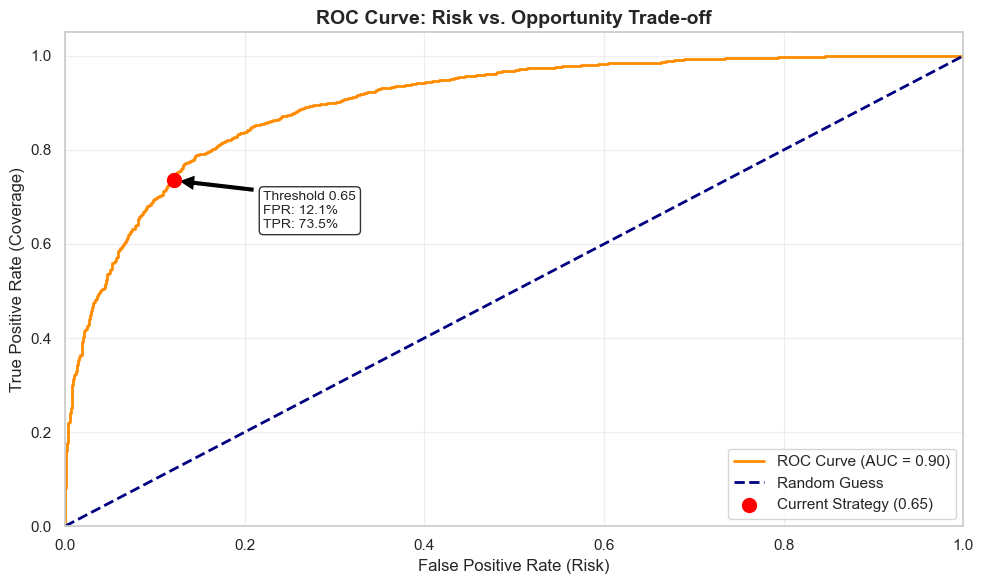

In [3]:
from sklearn.metrics import roc_curve, auc

# ==========================================
# PLOT 4: ROC CURVE (WITH THRESHOLD MARKER)
# ==========================================
plt.figure(figsize=(10, 6))

# 1. Calculate Curve
fpr, tpr, thresholds = roc_curve(df_inference['is_long_permit'], df_inference['p_allow_long'])
roc_auc = auc(fpr, tpr)

# 2. Plot Curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

# 3. Find and Plot the Point for Threshold = 0.65
# We look for the threshold in the list closest to 0.65
close_indices = np.where(thresholds >= THRESHOLD)[0]
if len(close_indices) > 0:
    idx = close_indices[-1] # Take the last one that satisfies the condition
    current_fpr = fpr[idx]
    current_tpr = tpr[idx]
    
    plt.scatter(current_fpr, current_tpr, s=100, c='red', zorder=10, label=f'Current Strategy ({THRESHOLD})')
    
    # Annotate the point
    plt.annotate(f'Threshold {THRESHOLD}\nFPR: {current_fpr:.1%}\nTPR: {current_tpr:.1%}', 
                 xy=(current_fpr, current_tpr), 
                 xytext=(current_fpr + 0.1, current_tpr - 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

# 4. Styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Risk)', fontsize=12)
plt.ylabel('True Positive Rate (Coverage)', fontsize=12)
plt.title('ROC Curve: Risk vs. Opportunity Trade-off', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_roc_curve.png')
plt.show()